In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import datasets, transforms
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset

In [ ]:
import functools

In [ ]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm

## Data Preparation (Filtering '1's and '8's)

In [ ]:
BATCH_SIZE = 32
IMG_SIZE = 28

In [ ]:
dataset = datasets.MNIST('.', train = True, transform=transforms.ToTensor(), download=True)


100%|██████████| 9.91M/9.91M [00:00<00:00, 17.9MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 485kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.44MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 7.43MB/s]


In [ ]:
idx = (dataset.targets == 1) | (dataset.targets == 8)
dataset.idx = dataset.targets[idx]
dataset.data = dataset.data[idx]

In [ ]:
dataset

Dataset MNIST
    Number of datapoints: 12593
    Root location: .
    Split: Train
    StandardTransform
Transform: ToTensor()

In [ ]:
data_loader = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=True)

In [ ]:
def image_visualizer(x):
  img = x

  # Remove the channel dimension (1) so it becomes (28, 28)
  img = img.squeeze(0)

  # Plot
  plt.imshow(img, cmap="gray")
  plt.axis("off")  # optional, hides axes
  plt.show()

In [ ]:
beta_min = 0.1
beta_max = 20.0

def beta(t, beta_min, beta_max):
    return beta_min + t * (beta_max - beta_min)

def drift(x, t):
    return -0.5 * beta(t, beta_min, beta_max) * x

def diffusion(t):
    return torch.sqrt(beta(t, beta_min, beta_max))

def forward_sde_step(x, t, dt):
    z = torch.randn_like(x)
    f = drift(x, t)
    g = diffusion(t)
    x_next = x + f * dt + g * torch.sqrt(dt) * z
    return x_next

In [ ]:
first_batch = next(iter(data_loader))
print(first_batch[0][0].shape)
x = first_batch[0][0]

torch.Size([1, 28, 28])


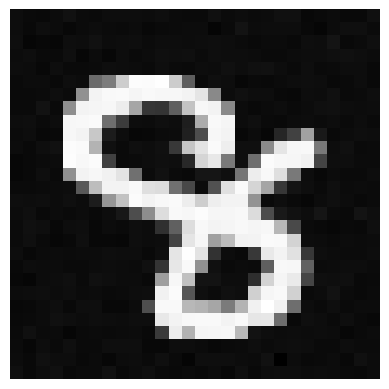

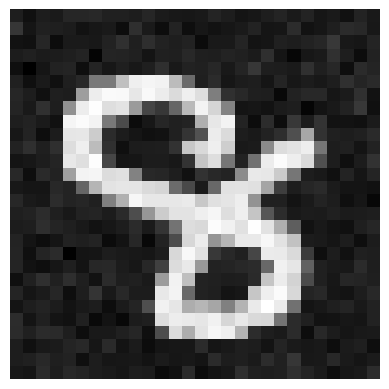

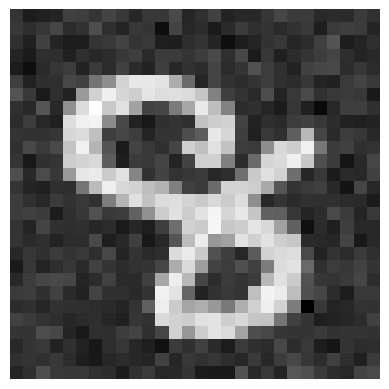

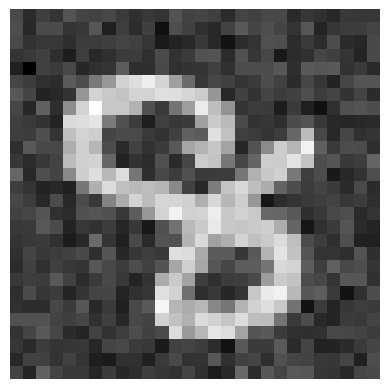

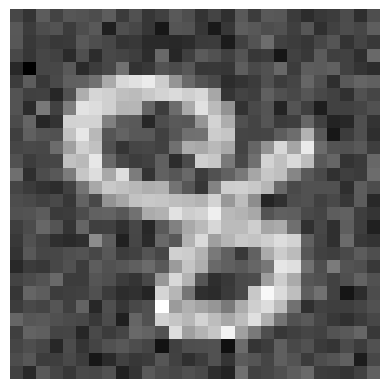

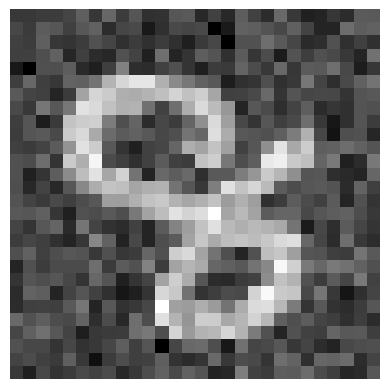

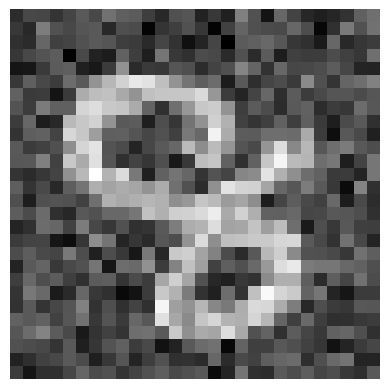

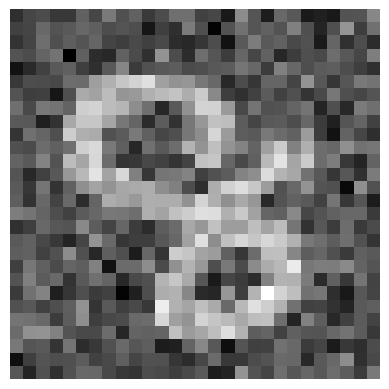

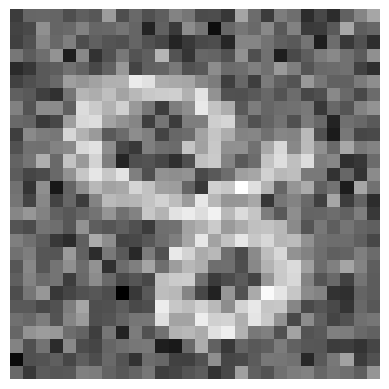

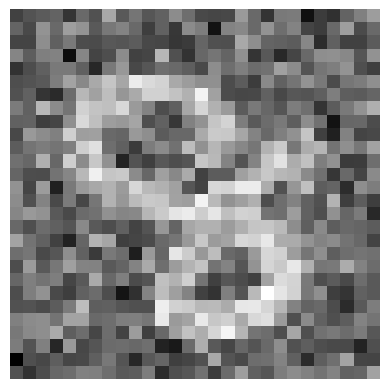

In [ ]:
N = 1000
dt = torch.tensor(1.0/N)
x_t = x.clone()
for i in range(N):
    t = dt * i
    x_t = forward_sde_step(x_t, t, dt)
    if(i%10 == 0 and i<100):
      image_visualizer(x_t)

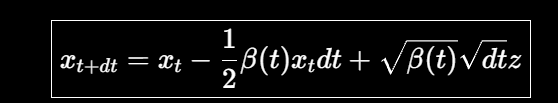

In [ ]:
class GaussianFourierProjection(nn.Module):
    ### Embeds scalar noise levels labels into vectors."""
    ### hey these is not applied over images else this is applied over sigma value to convert them into tensors
    def __init__(self, embed_dim, scale=30.0):
        super().__init__()
        # Randomly initialized frequencies, not trainable (standard practice in Score models)
        self.W = nn.Parameter(
            torch.randn(embed_dim // 2) * scale, requires_grad=False
        )    #### creates a vector of shape  (embed_dim//2, )

    def forward(self, x):
        x_proj = x[:, None] * self.W[None, :] * 2 * np.pi    ### (B, 1) * (1, embed_dim//2) --> (B, embed_dim//2)  **** here B refers to num of sigma values
        return torch.cat([torch.sin(x_proj), torch.cos(x_proj)], dim=-1)    ### (B, embed_dim)


class ScoreNet(nn.Module):
    def __init__(self, channels=[32, 64, 128, 256], embed_dim=256):
        super().__init__()

        # Gaussian Fourier Projection for noise levels
        self.embed = GaussianFourierProjection(embed_dim)

        # U-Net Encoder
        self.conv1 = nn.Conv2d(1, channels[0], 3, stride=1, padding=1)
        self.dense1 = nn.Linear(embed_dim, channels[0])
        self.gn1 = nn.GroupNorm(4, channels[0])

        self.conv2 = nn.Conv2d(channels[0], channels[1], 3, stride=2, padding=1)
        self.dense2 = nn.Linear(embed_dim, channels[1])
        self.gn2 = nn.GroupNorm(32, channels[1])

        self.conv3 = nn.Conv2d(channels[1], channels[2], 3, stride=2, padding=1)
        self.dense3 = nn.Linear(embed_dim, channels[2])
        self.gn3 = nn.GroupNorm(32, channels[2])
        self.tconv2 = nn.ConvTranspose2d(channels[2], channels[1], 3, stride=2, padding=1, output_padding=1)
        self.dense4 = nn.Linear(embed_dim, channels[1])
        self.gn4 = nn.GroupNorm(32, channels[1])

        self.tconv1 = nn.ConvTranspose2d(channels[1] * 2, channels[0], 3, stride=2, padding=1, output_padding=1) # *2 for skip con
        self.dense5 = nn.Linear(embed_dim, channels[0])
        self.gn5 = nn.GroupNorm(32, channels[0])

        self.final = nn.Conv2d(channels[0] * 2, 3, 3, stride=1, padding=1)

        self.act = nn.SiLU() # Swish activation

    def forward(self, x, t):
        # # Embed the noise level
        embed = self.act(self.embed(t))

        # # Encoding
        h1 = self.conv1(x)

        # # Add conditioning: Feature map + Embedding
        h1 += self.dense1(embed)[..., None, None]
        h1 = self.act(self.gn1(h1))

        h2 = self.conv2(h1)
        h2 += self.dense2(embed)[..., None, None]
        h2 = self.act(self.gn2(h2))

        h3 = self.conv3(h2)
        h3 += self.dense3(embed)[..., None, None]
        h3 = self.act(self.gn3(h3))

        # Decoding with Skip Connections
        h2_dec = self.tconv2(h3)
        h2_dec += self.dense4(embed)[..., None, None]
        h2_dec = self.act(self.gn4(h2_dec))

        # Skip connection from encoder h2
        h2_cat = torch.cat([h2_dec, h2], dim=1)

        h1_dec = self.tconv1(h2_cat)
        h1_dec += self.dense5(embed)[..., None, None]
        h1_dec = self.act(self.gn5(h1_dec))

        # Skip connection from encoder h1
        h1_cat = torch.cat([h1_dec, h1], dim=1)

        out = self.final(h1_cat)

        # Normalize output by sigma (Paper trick: estimate s(x) * sigma instead of s(x)
        # We return the raw output; the loss handles the scaling.
        return out


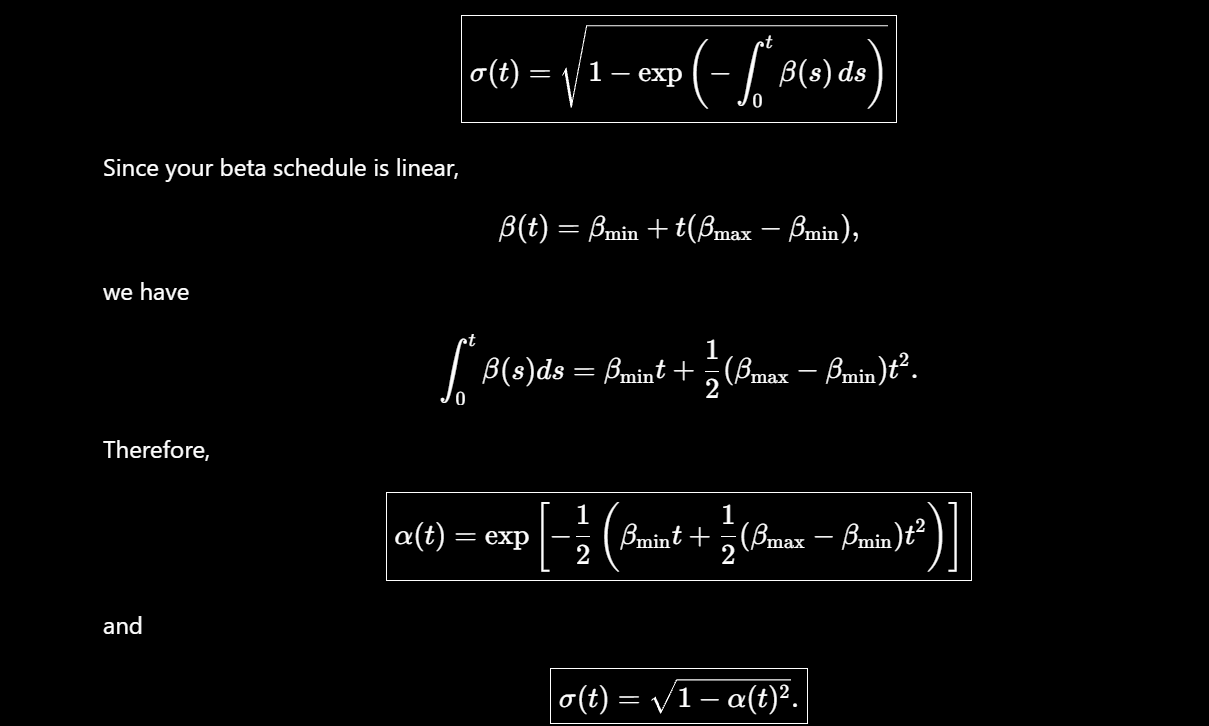

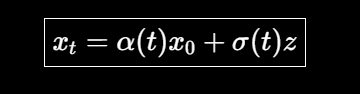

In [ ]:
def beta(t):
    return beta_min + t * (beta_max - beta_min)


def alpha(t):
    integral_beta = (
        beta_min * t
        + 0.5 * (beta_max - beta_min) * t**2
    )

    return torch.exp(-0.5 * integral_beta)


def sigma(t):
    a = alpha(t)
    return torch.sqrt(1.0 - a**2)


def loss_fn(model, x, eps=1e-5):

    # Sample t
    t = torch.rand(x.shape[0], device=x.device)    ### create a tensor of shape(B,) which is uniformly distributed between [0, 1]
    t = t * (1.0 - eps) + eps  ### t becomes [0, 1-eps] -> [eps, 1]

    # VP SDE marginal parameters
    a = alpha(t)
    s = sigma(t)

    # Gaussian noise
    z = torch.randn_like(x)

    ### Sample x_t directly
    x_t = (a[:, None, None, None] * x + s[:, None, None, None] * z )

    # Predict score
    score = model(x_t, t)

    # Denoising score matching
    loss = torch.mean(torch.sum((score * s[:, None, None, None] + z) ** 2, dim=(1, 2, 3)))

    return loss

In [ ]:
score_model = ScoreNet().to(device)
optimizer = torch.optim.Adam(score_model.parameters(), lr=1e-4)


In [ ]:
num_epochs = 10
for epoch in range(num_epochs):
  avg_loss = 0
  num_items = 0
  for batch_features, batch_labels in tqdm(data_loader):
    batch_features, batch_labels = batch_features.to(device), batch_labels.to(device)
    loss = loss_fn(score_model, batch_features)
    optimizer.zero_grad()
    loss.backward()
    avg_loss += loss.item() * batch_features.shape[0]
    num_items += batch_features.shape[0]
    optimizer.step()

  print(f"avg. loss per image is {avg_loss/num_items}")

100%|██████████| 394/394 [00:05<00:00, 73.28it/s]


avg. loss per image is 621.9753623180258


100%|██████████| 394/394 [00:05<00:00, 73.83it/s] 


avg. loss per image is 242.3398817118873


100%|██████████| 394/394 [00:03<00:00, 105.80it/s]


...

avg. loss per image is 103.06536888377619


100%|██████████| 394/394 [00:04<00:00, 94.25it/s]


avg. loss per image is 93.44602046455523


100%|██████████| 394/394 [00:03<00:00, 102.57it/s]

avg. loss per image is 85.63556481452795


In [ ]:
def euler_maruyama_sampler(score_model, sigma, drift, diffusion, batch_size=64, num_steps=500, device=device ):
    # Start from approximately Gaussian noise at t = 1
    t = torch.ones(batch_size, device=device)
    init_x = (torch.randn(batch_size, 1, 28, 28, device=device) * sigma(t)[:, None, None, None])

    time_steps = torch.linspace(1.0, 1e-3, num_steps, device=device)

    step_size = time_steps[0] - time_steps[1]

    x = init_x

    with torch.no_grad():

        for time_step in tqdm(time_steps):

            batch_time_step = torch.full((batch_size,), time_step, device=device)
            # Forward SDE drift
            f = drift(x, batch_time_step)
            # Forward SDE diffusion coefficient
            g = diffusion(batch_time_step)
            # Score network
            score = score_model(x, batch_time_step)

            # Reverse SDE drift
            reverse_drift = -f + (g[:, None, None, None] ** 2) * score

            # Euler-Maruyama step backward in time
            x_mean = x + reverse_drift * step_size

            # Stochastic part
            noise = torch.randn_like(x)

            x = (x_mean + g[:, None, None, None] * torch.sqrt(step_size) * noise)

    return x_mean